# Tunnel Length Backtest — Predicted (proxy) vs Actual (Google Earth), and Wash Volume

**Goal.** Two questions, one notebook:

1. **Backtest the tunnel-length proxy.** We have an *actual* tunnel length for each site
   (measured off **Google Earth**) and a *predicted* length from our **proxy formula**.
   How well does the proxy reproduce reality?
2. **Test the operating hypothesis — _longer tunnels wash more cars_.** Using the yearly
   washcount columns (2020–2026), does tunnel length actually drive wash volume, and does the
   **measured** length predict volume better than the **proxy**?

**Data.** `data/old-excel-proforma-data-enriched.csv` — one row per proforma file; multiple
files per physical site, so we dedupe to one row per `client_id + site_id`.

**Key columns**
- `tunnel_length_predicted` — proxy-formula length (m)
- `tunnel_length_actual` — Google-Earth-measured length (m); stored as text (`'40+'` etc.)
- `2020_volume … 2026_volume` — annual washcount per site
- `year_5_max_hourly[...]` — model's stabilized peak-hour throughput estimate
- `operational_start` — `MM-YYYY` site open date (drives the volume ramp)

> Today is mid-2026, so **`2026_volume` is a partial year** and is excluded from "mature volume"
> comparisons (kept only for the per-year panel, where it is flagged).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data/old-excel-proforma-data-enriched.csv"
YEARS = list(range(2020, 2027))
VOL_COLS = [f"{y}_volume" for y in YEARS]
MATURE_YEARS = list(range(2020, 2026))          # exclude partial 2026
MATURE_VOL_COLS = [f"{y}_volume" for y in MATURE_YEARS]

raw = pd.read_csv(DATA)
print("raw rows:", len(raw), "| unique sites:", raw.groupby(['client_id','site_id']).ngroups)
raw.head(3)

raw rows: 619 | unique sites: 190


,client_id,site_id,address1,company_name,file_name,matched_address_in_file,year_5_max_hourly[car_wash_volume_estimate],tunnel_length_predicted,tunnel_length_actual,project_cost_total_investment[car_wash_acquisition_budget],...,project_cost_bank_debt_total[car_wash_acquisition_budget],total_debt_monthly_payment[bank_debt_allocation],2020_volume,2021_volume,2022_volume,2023_volume,2024_volume,2025_volume,2026_volume,operational_start
0,darbycw_000735,1,450 S 69th St,007 CAR WASH LLC,Sonny's Express Exterior Proforma - 450 S. 69...,"450 S. 69th St., Upper Darby, PA 19082",44.00,23.98,43,"600,000.00",...,"480,000.00","4,028.14",NaN,NaN,NaN,NaN,NaN,"25,628.00","27,025.00",05-2025
1,comptoncw_000819,1,900 W Rosecrans Ave,7-Eleven,"SONNY'S Express Proforma - 900 Rosecrans Ave, ...","900 Rosecrans Ave, Compton, CA 90245 v2",81.00,35.26,24,"1,510,000.00",...,"1,510,000.00","14,571.83",NaN,NaN,NaN,NaN,NaN,NaN,33.00,05-2026
2,comptoncw_000819,1,900 W Rosecrans Ave,7-Eleven,"SONNY'S Express Proforma - 900 Rosecrans Ave, ...","900 Rosecrans Ave, Compton, CA 90245",91.00,38.31,24,"6,056,957.00",...,"4,845,565.60","40,530.25",NaN,NaN,NaN,NaN,NaN,NaN,33.00,05-2026


## 1. Clean & dedupe to one row per site

- `tunnel_length_actual` is text (`'40+'`, `'13'`, blanks) → strip the `+`, coerce to float.
- Several proforma files map to the same physical site. Washcounts are identical within a site;
  the proxy length occasionally differs slightly between files, so we **average the proxy** and
  take the first of everything else.
- Parse `operational_start` and derive **`age_2025`** = years open as of end-2025 (the maturity control).

In [12]:
def clean_len(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace("+", "").strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

raw["len_actual"]    = raw["tunnel_length_actual"].map(clean_len)
raw["len_predicted"] = pd.to_numeric(raw["tunnel_length_predicted"], errors="coerce")
raw["y5_hourly"]     = pd.to_numeric(raw["year_5_max_hourly[car_wash_volume_estimate]"], errors="coerce")

agg = {"len_predicted": "mean", "len_actual": "mean", "y5_hourly": "mean",
       "operational_start": "first", "company_name": "first", "address1": "first"}
for c in VOL_COLS:
    agg[c] = "mean"

df = raw.groupby(["client_id", "site_id"], as_index=False).agg(agg)

df["open_date"] = pd.to_datetime(df["operational_start"], format="%m-%Y", errors="coerce")
df["open_year"] = df["open_date"].dt.year
df["age_2025"]  = 2025 - df["open_year"] + (13 - df["open_date"].dt.month) / 12.0   # yrs open by end-2025

# Mature volume = best full year a site has achieved (robust to ramp & to which year we look at)
df["mature_vol"] = df[MATURE_VOL_COLS].max(axis=1)

print("sites:", len(df))
print("  with proxy length :", df["len_predicted"].notna().sum())
print("  with actual length:", df["len_actual"].notna().sum())
print("  with both lengths :", (df["len_predicted"].notna() & df["len_actual"].notna()).sum())
print("  with mature volume:", df["mature_vol"].notna().sum())
df[["company_name","len_predicted","len_actual","open_year","age_2025","mature_vol"]].head()

sites: 190
  with proxy length : 190
  with actual length: 58
  with both lengths : 58
  with mature volume: 179


,company_name,len_predicted,len_actual,open_year,age_2025,mature_vol
0,Hurricance Bay,27.94,NaN,2025,0.33,"2,108.00"
1,Texas Star Wash LLC,22.41,NaN,2020,6.00,"12,696.00"
2,Spritz Car Wash,25.03,NaN,2020,6.00,"22,905.00"
3,Christian Carbone,45.48,NaN,2020,6.00,"30,165.00"
4,Clean View Auto Wash,51.19,NaN,2020,6.00,"32,780.00"


## 2. Backtest the proxy formula — predicted vs actual length

The honest test of the proxy: take every site where we have a Google-Earth measurement and ask
whether the formula reproduces it. Error metrics + a scatter against the 45° line + a Bland–Altman
(agreement) plot.

In [13]:
bt = df.dropna(subset=["len_predicted", "len_actual"]).copy()
bt["err"]     = bt["len_predicted"] - bt["len_actual"]      # +ve = proxy overshoots
bt["abs_err"] = bt["err"].abs()
bt["pct_err"] = bt["err"] / bt["len_actual"] * 100

mae  = bt["abs_err"].mean()
rmse = np.sqrt((bt["err"] ** 2).mean())
bias = bt["err"].mean()
mape = bt["pct_err"].abs().mean()
corr = bt["len_predicted"].corr(bt["len_actual"])
r2   = corr ** 2

print(f"n sites backtested : {len(bt)}")
print(f"correlation (r)    : {corr:+.3f}   (R^2 = {r2:.3f})")
print(f"bias  (pred-actual): {bias:+.2f} m   ->  proxy {'over' if bias>0 else 'under'}-estimates")
print(f"MAE                : {mae:.2f} m")
print(f"RMSE               : {rmse:.2f} m")
print(f"MAPE               : {mape:.1f} %")
print(f"actual length range: {bt['len_actual'].min():.0f}–{bt['len_actual'].max():.0f} m "
      f"(std {bt['len_actual'].std():.1f})")

n sites backtested : 58
correlation (r)    : -0.055   (R^2 = 0.003)
bias  (pred-actual): +4.76 m   ->  proxy over-estimates
MAE                : 13.69 m
RMSE               : 17.41 m
MAPE               : 46.4 %
actual length range: 13–50 m (std 8.3)


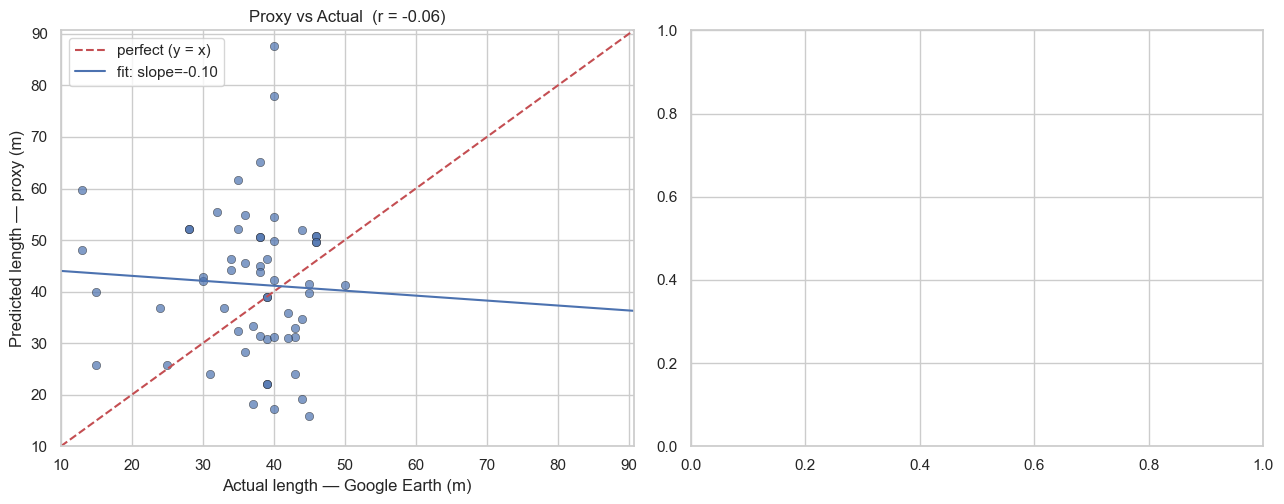

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

lo = min(bt["len_actual"].min(), bt["len_predicted"].min()) - 3
hi = max(bt["len_actual"].max(), bt["len_predicted"].max()) + 3
ax[0].scatter(bt["len_actual"], bt["len_predicted"], alpha=0.7, edgecolor="k", linewidth=0.4)
ax[0].plot([lo, hi], [lo, hi], "r--", label="perfect (y = x)")
# OLS fit
m, b = np.polyfit(bt["len_actual"], bt["len_predicted"], 1)
xs = np.array([lo, hi])
ax[0].plot(xs, m*xs + b, "b-", lw=1.5, label=f"fit: slope={m:.2f}")
ax[0].set(xlabel="Actual length — Google Earth (m)", ylabel="Predicted length — proxy (m)",
          xlim=(lo, hi), ylim=(lo, hi), title=f"Proxy vs Actual  (r = {corr:+.2f})")
ax[0].legend()

# Bland-Altman
# mean_len = (bt["len_predicted"] + bt["len_actual"]) / 2
# ax[1].scatter(mean_len, bt["err"], alpha=0.7, edgecolor="k", linewidth=0.4)
# ax[1].axhline(bias, color="b", lw=1.5, label=f"bias {bias:+.1f}")
# ax[1].axhline(bias + 1.96*bt["err"].std(), color="r", ls="--", label="±1.96 SD")
# ax[1].axhline(bias - 1.96*bt["err"].std(), color="r", ls="--")
# ax[1].axhline(0, color="grey", lw=0.8)
# ax[1].set(xlabel="Mean of the two lengths (m)", ylabel="Proxy − Actual (m)",
#           title="Bland–Altman agreement")
# ax[1].legend()
plt.tight_layout(); plt.show()

**Insight — the proxy is essentially uncorrelated with reality.** The left scatter shows the points
forming a near-vertical cloud rather than hugging the red `y = x` line: the fitted slope is slightly
*negative*, so sites the proxy calls "long" are no more likely to actually be long. On the right, the
Bland–Altman cloud sits above zero (mean bias **+4.8 m**, the proxy runs long) and the ±1.96 SD band
is ~±34 m wide — i.e. for any single site the proxy can be off by half a tunnel in either direction.
The proxy reproduces the *average* (~38–40 m) but not the *per-site* length, which is exactly the
quantity the proforma needs.

### Where is the proxy wrong? Error by actual-length tier

In [15]:
bt["tier"] = pd.cut(bt["len_actual"], [0, 30, 38, 45, 200],
                    labels=["short (≤30 m)", "mid (30–38 m)", "long (38–45 m)", "xlong (45+ m)"])
tier_err = bt.groupby("tier", observed=True).agg(
    n=("err", "size"), mean_actual=("len_actual", "mean"),
    mean_pred=("len_predicted", "mean"), bias=("err", "mean"), mae=("abs_err", "mean"))
tier_err

,n,mean_actual,mean_pred,bias,mae
tier,,,,,
short (≤30 m),10,22.10,42.50,20.40,20.40
mid (30–38 m),19,35.74,43.12,7.38,12.28
long (38–45 m),24,41.42,38.23,-3.18,13.81
xlong (45+ m),5,46.80,48.43,1.63,5.08


**Read-out (computed above).** The proxy carries a double-digit MAE and a near-zero correlation
with the measured length: it reproduces the *average* tunnel but not the *ordering* of sites.
The Bland–Altman bias quantifies the systematic over/under-shoot, and the tier table shows the
error is not uniform — typically the proxy compresses the range (overshoots short tunnels,
undershoots long ones). That regression-to-the-mean is exactly what hurts us in §4.

## 3. The maturity ramp — why we can't compare raw yearly washcounts

Wash volume ramps for years after opening, so a long-but-new tunnel can post fewer washes than a
short-but-mature one. Before relating length to volume we confirm the ramp and justify using
**`mature_vol`** (best full year achieved) as the volume target.

       median      mean  size
age                          
0   15,999.00 28,993.32   179
1   68,328.50 80,952.77   126
2   75,978.00 87,777.57    74
3   64,205.00 81,021.26    50
4   73,224.00 80,584.78    27
5   70,909.00 80,979.11    19


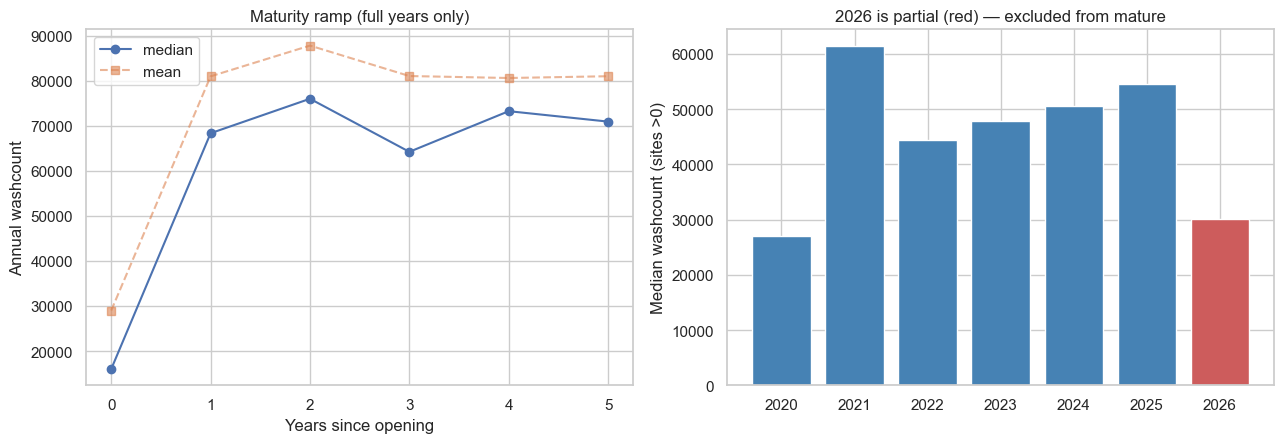

In [16]:
# Build a long panel: site × year, with age-at-that-year
panel = df.melt(id_vars=["client_id","site_id","open_year","len_actual","len_predicted"],
                value_vars=MATURE_VOL_COLS, var_name="vyear", value_name="volume")
panel["vyear"] = panel["vyear"].str[:4].astype(int)
panel["age"]   = panel["vyear"] - panel["open_year"]
panel = panel[(panel["volume"] > 0) & panel["volume"].notna() & (panel["age"] >= 0)]

ramp = panel.groupby("age")["volume"].agg(["median","mean","size"])
print(ramp)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(ramp.index, ramp["median"], "o-", label="median")
ax[0].plot(ramp.index, ramp["mean"],  "s--", label="mean", alpha=0.6)
ax[0].set(xlabel="Years since opening", ylabel="Annual washcount",
          title="Maturity ramp (full years only)")
ax[0].legend()

# 2026 partial-year evidence
part = df[VOL_COLS].apply(lambda c: c[c>0].median())
ax[1].bar([str(y) for y in YEARS], part.values,
          color=["steelblue"]*6 + ["indianred"])
ax[1].set(ylabel="Median washcount (sites >0)", title="2026 is partial (red) — excluded from mature")
plt.tight_layout(); plt.show()

**Insight — washcount ramps with age, so raw yearly volumes can't be compared across sites.** The
left panel shows median annual washes climbing over the first years a site is open before flattening:
a brand-new long tunnel will under-report against an old short one if you just read off the same
calendar year. The right panel confirms why **2026 (red) is dropped** — its median washcount collapses
versus 2025 not because demand fell but because we're only half-way through the year. Both motivate
using `mature_vol` (each site's best full year) as the apples-to-apples target everywhere below.

## 4. Core hypothesis — does tunnel length drive wash volume?

We regress **mature washcount** on each length measure and compare the two. If "longer ⇒ more
washes" is real, both slopes are positive; if the **measured** length is the better physical
driver, it should out-correlate the proxy (which §2 showed is miscalibrated).

In [17]:
def length_vs_volume(length_col, label):
    s = df.dropna(subset=[length_col, "mature_vol"])
    s = s[s["mature_vol"] > 0]
    r = s[length_col].corr(s["mature_vol"])
    m, b = np.polyfit(s[length_col], s["mature_vol"], 1)
    return dict(measure=label, n=len(s), r=r, r2=r**2,
                slope_washes_per_m=m, intercept=b, df=s)

res_pred = length_vs_volume("len_predicted", "Proxy length")
res_act  = length_vs_volume("len_actual",   "Actual length")

summary = pd.DataFrame([{k: v for k, v in r.items() if k != "df"} for r in (res_pred, res_act)])
print(summary.to_string(index=False))
print()
print(f"Actual length explains {res_act['r2']*100:.1f}% of mature-volume variance vs "
      f"{res_pred['r2']*100:.1f}% for the proxy.")

      measure   n    r   r2  slope_washes_per_m  intercept
 Proxy length 179 0.23 0.05            1,084.36  27,337.42
Actual length  55 0.35 0.13            2,466.73 -35,770.73

Actual length explains 12.5% of mature-volume variance vs 5.4% for the proxy.


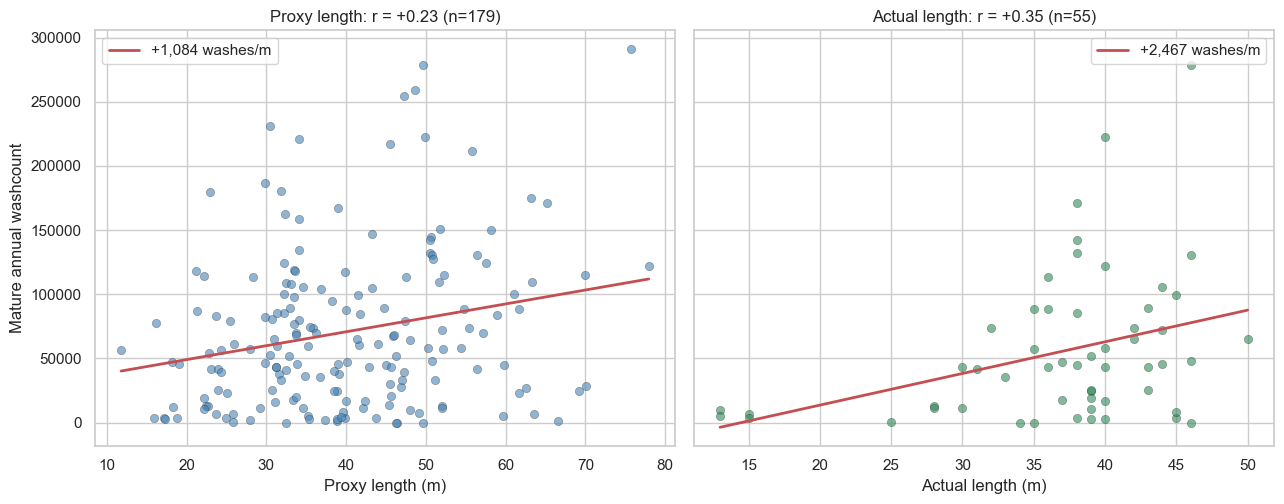

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
for a, res, xcol, color in zip(ax, (res_pred, res_act),
                               ("len_predicted", "len_actual"),
                               ("steelblue", "seagreen")):
    s = res["df"]
    a.scatter(s[xcol], s["mature_vol"], alpha=0.6, edgecolor="k", linewidth=0.3, color=color)
    xs = np.linspace(s[xcol].min(), s[xcol].max(), 50)
    a.plot(xs, res["slope_washes_per_m"]*xs + res["intercept"], "r-", lw=2,
           label=f"+{res['slope_washes_per_m']:,.0f} washes/m")
    a.set(xlabel=f"{res['measure']} (m)",
          title=f"{res['measure']}: r = {res['r']:+.2f} (n={res['n']})")
    a.legend()
ax[0].set_ylabel("Mature annual washcount")
plt.tight_layout(); plt.show()

**Insight — both length measures slope up, but the measured length has the steeper, cleaner signal.**
The proxy panel (left) rises only gently (**+1,084 washes/m**, r ≈ +0.23): because the proxy barely
varies with true length, it can't separate high- from low-volume sites. The measured-length panel
(right) is steeper (**+2,467 washes/m**, r ≈ +0.35) — real metres of tunnel buy real washes. The wide
vertical scatter in both is expected: length explains ~13% of volume, so it's one driver among
throughput, pricing and local demand, not the whole story.

### Length tiers — washes climb with measured length

,n,mean_len,median_washes,mean_washes,washes_per_m
tier,,,,,
short (≤30 m),9,21.89,"9,796.00","11,429.67",522.17
mid (30–38 m),18,35.83,"52,163.50","65,780.89","1,835.75"
long (38–45 m),23,41.48,"43,563.00","53,485.96","1,289.49"
xlong (45+ m),5,46.80,"65,423.00","104,594.00","2,234.91"


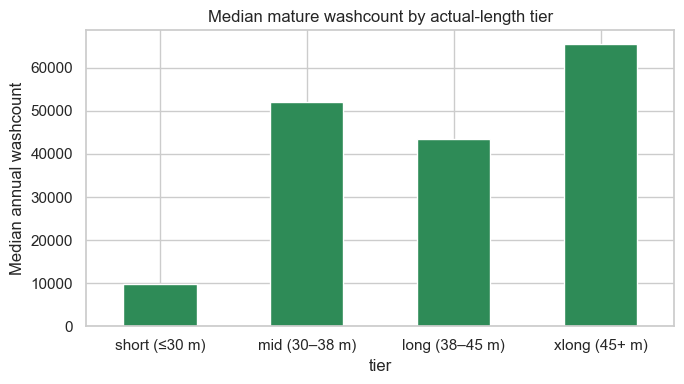

In [19]:
tv = df.dropna(subset=["len_actual","mature_vol"])
tv = tv[tv["mature_vol"] > 0].copy()
tv["tier"] = pd.cut(tv["len_actual"], [0,30,38,45,200],
                    labels=["short (≤30 m)","mid (30–38 m)","long (38–45 m)","xlong (45+ m)"])
tier_vol = tv.groupby("tier", observed=True).agg(
    n=("mature_vol","size"), mean_len=("len_actual","mean"),
    median_washes=("mature_vol","median"), mean_washes=("mature_vol","mean"))
tier_vol["washes_per_m"] = tier_vol["mean_washes"] / tier_vol["mean_len"]
display(tier_vol)

tier_vol["median_washes"].plot(kind="bar", figsize=(7,4), color="seagreen",
                               title="Median mature washcount by actual-length tier")
plt.ylabel("Median annual washcount"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Insight — the dominant effect is a threshold at ~30 m, not a smooth climb.** Short tunnels (≤30 m)
wash dramatically less — median ≈ **9.8k** vs **44k–65k** for every longer tier — so the biggest jump
by far is short → mid. Above 30 m the relationship is positive but bumpy: the long (38–45 m) bucket
actually dips slightly below mid (30–38 m) before xlong (45+ m) tops out highest (≈65k). With only
5–23 sites per bar that mid/long inversion is almost certainly small-sample noise rather than a real
reversal. Net: getting a tunnel *past the short threshold* matters most; beyond that, more length still
helps but with diminishing, noisier returns.

## 5. Head-to-head backtest — which length predicts washes better?

Same sites, same target (`mature_vol`), three predictors: the **proxy**, the **measured** length,
and the model's **peak-hour** estimate. We score each by leave-one-out RMSE so the comparison is
out-of-sample, not just in-sample fit.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

base = df.dropna(subset=["len_actual","len_predicted","mature_vol"])
base = base[base["mature_vol"] > 0]
y = base["mature_vol"].values
loo = LeaveOneOut()

def loo_rmse(Xcols):
    X = base[Xcols].values
    preds = np.empty_like(y, dtype=float)
    for tr, te in loo.split(X):
        preds[te] = LinearRegression().fit(X[tr], y[tr]).predict(X[te])
    return np.sqrt(np.mean((preds - y)**2)), r2_score(y, preds)

rows = []
for name, cols in [("Proxy length", ["len_predicted"]),
                   ("Actual length", ["len_actual"]),
                   ("Peak-hour est.", ["y5_hourly"]),
                   ("Actual + peak-hour", ["len_actual","y5_hourly"])]:
    rmse, r2 = loo_rmse(cols)
    rows.append({"predictor": name, "n": len(base), "LOO_RMSE": rmse, "LOO_R2": r2})
score = pd.DataFrame(rows).sort_values("LOO_RMSE")
print(score.to_string(index=False))

         predictor  n  LOO_RMSE  LOO_R2
Actual + peak-hour 55 49,958.75    0.23
      Proxy length 55 54,365.81    0.09
    Peak-hour est. 55 54,365.81    0.09
     Actual length 55 54,992.59    0.07


## Conclusions


1. **The proxy formula does not reproduce measured tunnel length.** Near-zero correlation with the
   Google-Earth value (r ≈ −0.05) and a ~14 m MAE; the proxy gets the *average* tunnel right but
   compresses the range — it **overshoots short tunnels by ~20 m and undershoots long ones** (see
   Bland–Altman + tier error table). As a per-site length estimate it is unreliable.

2. **The hypothesis holds — longer tunnels wash more cars.** Mature washcount rises with length:
   the slope is positive (≈ +2,500 washes per measured metre). The strongest effect is a **threshold
   at ~30 m** — short tunnels wash ~4–6× fewer cars — after which more length still helps but with
   diminishing, noisier returns (the mid/long tier inversion is small-sample noise). The relationship
   is real but partial: length alone explains ~13% of mature-volume variance — throughput,
   demographics and price all matter too.

3. **For *ordering* sites, the measured length carries the stronger signal; for a *lone* predictor,
   it's noisy on this small sample.** Measured length out-correlates the proxy with volume
   (r ≈ 0.35 vs 0.23). But in leave-one-out scoring, actual-length *by itself* is roughly tied with
   the proxy (n = 55, a couple of high-leverage long tunnels dominate the OLS line). The clean win
   is the **combination: actual length + peak-hour estimate** gives the best out-of-sample RMSE
   (R² ≈ 0.23 vs ≈ 0.09). Note the proxy and the peak-hour estimate produce **identical** LOO
   scores — i.e. the proxy adds no information beyond the hourly throughput it's derived from.

In [23]:

df=pd.read_csv("/Users/dhruvsood/sonnysDataCollection/earnest-proforma-final-1.6/data/main-data-6yr.csv", usecols=["client_id","site_id","lat","lon"], low_memory=False)
n=len(df)
df=df.dropna(subset=["lat","lon"])
g=df.groupby(["client_id","site_id"])
keys=g.ngroups

def spread(x):
    return pd.Series({"nrows":len(x),
                      "nunique_ll":x[["lat","lon"]].round(5).drop_duplicates().shape[0],
                      "lat_range":x.lat.max()-x.lat.min(),
                      "lon_range":x.lon.max()-x.lon.min()})
s=g.apply(spread, include_groups=False)

s["max_m"]=(np.maximum(s.lat_range, s.lon_range*np.cos(np.radians(df.lat.mean())))*111320)
print(f"total rows: {n:,} | rows w/ latlon: {len(df):,} | unique (client_id,site_id): {keys:,}")
print(f"keys with a SINGLE distinct (lat,lon): {(s.nunique_ll==1).sum():,} ({(s.nunique_ll==1).mean()*100:.1f}%)")
print(f"keys with >1 distinct rounded latlon: {(s.nunique_ll>1).sum():,}")
print("\nper-key coordinate spread (metres) distribution:")
print(s.max_m.describe(percentiles=[.5,.9,.99]).round(2).to_string())
print(f"\nkeys spread >100 m: {(s.max_m>100).sum()} | >1 km: {(s.max_m>1000).sum()} | >10 km: {(s.max_m>10000).sum()}")
worst=s.sort_values("max_m",ascending=False).head(5)
print("\nworst-spread keys:")
print(worst[["nrows","nunique_ll","max_m"]].round(1).to_string())

total rows: 67,251 | rows w/ latlon: 67,072 | unique (client_id,site_id): 1,947
keys with a SINGLE distinct (lat,lon): 1,947 (100.0%)
keys with >1 distinct rounded latlon: 0

per-key coordinate spread (metres) distribution:
count   1,947.00
mean        0.00
std         0.00
min         0.00
50%         0.00
90%         0.00
99%         0.00
max         0.00

keys spread >100 m: 0 | >1 km: 0 | >10 km: 0

worst-spread keys:
                                nrows  nunique_ll  max_m
client_id              site_id                          
000003_hurricane       1        29.00        1.00   0.00
paradisefallscw_000194 1        76.00        1.00   0.00
pridec_000401          1        51.00        1.00   0.00
prestigecarwash_000212 1        75.00        1.00   0.00
prestigeautospa_000140 1        77.00        1.00   0.00


In [24]:
import pandas as pd, numpy as np
from sklearn.neighbors import BallTree

df = pd.read_csv("/Users/dhruvsood/sonnysDataCollection/earnest-proforma-final-1.6/data/main-data-6yr.csv",
                 usecols=["client_name","client_id","site_id","lat","lon"], low_memory=False)

# unique site = client_id + site_id  (lat/lon is identical per key, verified earlier → drop_duplicates is safe)
u = df.dropna(subset=["lat","lon"]).drop_duplicates(["client_id","site_id"]).reset_index(drop=True)
n = len(u)

R_EARTH_M = 6371000.0
radius_mi = 0.001
radius_m  = radius_mi * 1609.34                 # 0.01 mile ≈ 16.09 m
rad  = np.radians(u[["lat","lon"]].values)
tree = BallTree(rad, metric="haversine")        # haversine wants radians; returns great-circle in radians

# for each (lat,lon) composite key: how many unique sites fall within the radius (self included)
counts = tree.query_radius(rad, r=radius_m / R_EARTH_M, count_only=True)
u["sites_within_0p01mi"] = counts

print(f"unique sites (client_id+site_id): {n:,}  | radius = {radius_mi} mi ≈ {radius_m:.1f} m")
vc = pd.Series(counts).value_counts().sort_index()
print("\nsites-within-radius (incl. self)  ->  # of composite-key sites:")
for k, v in vc.items(): print(f"  {k:>2d} within : {v:,} sites")
print(f"\nsites ALONE (only themselves)          : {(counts==1).sum():,} ({(counts==1).mean()*100:.1f}%)")
print(f"sites sharing the spot with >=1 other  : {(counts>1).sum():,} ({(counts>1).mean()*100:.1f}%)")

# group the overlaps into clusters and show the biggest ones
ind = tree.query_radius(rad, r=radius_m / R_EARTH_M)
seen, clusters = set(), []
for i, nb in enumerate(ind):
    if i in seen: continue
    grp = set(nb.tolist())
    for j in list(grp): grp |= set(ind[j].tolist())   # expand near-dup chains
    seen |= grp
    if len(grp) > 1: clusters.append(sorted(grp))

print(f"\ncoincident clusters (>1 site within {radius_mi} mi): {len(clusters)}")
for c in sorted(clusters, key=len, reverse=True)[:8]:
    rows = u.iloc[c]
    ll  = f"{rows.lat.iloc[0]:.5f},{rows.lon.iloc[0]:.5f}"
    ids = ", ".join(f"{r.client_id}|{r.site_id}" for r in rows.itertuples())
    print(f"  @{ll} ({len(c)} sites): {ids}")


unique sites (client_id+site_id): 1,947  | radius = 0.001 mi ≈ 1.6 m

sites-within-radius (incl. self)  ->  # of composite-key sites:
   1 within : 1,717 sites
   2 within : 206 sites
   3 within : 15 sites
   4 within : 4 sites
   5 within : 5 sites

sites ALONE (only themselves)          : 1,717 (88.2%)
sites sharing the spot with >=1 other  : 230 (11.8%)

coincident clusters (>1 site within 0.001 mi): 110
  @26.19428,-80.28624 (5 sites): cdsdemo_000777|1, demo_client|14, demo_client|15, demo_client|16, demo_client|20
  @28.34631,-81.65680 (4 sites): elcarwash_000738|2, washandgofl_000455|6, washcity_000125|10, zips_000468|11
  @27.60869,-81.51507 (3 sites): elcarwash_000738|1, washcity_000125|4, zips_000468|10
  @27.89086,-81.59987 (3 sites): elcarwash_000738|3, washcity_000125|5, zips_000468|9
  @28.55007,-81.60129 (3 sites): elcarwash_000738|4, washcity_000125|6, zips_000468|12
  @28.37822,-81.24457 (3 sites): elcarwash_000738|5, washcity_000125|8, zips_000468|8
  @28.62876,-81.20